# Task 2: Persuasion in Australian Facebook Political Ads (APA22)

**Paper:** *Towards Detecting Persuasion on Social Media: From Model Development to Insights on Persuasion Strategies*  
**Authors:** Meguellati et al. (2025)

This notebook covers Task 2 of the paper: applying the PPAsy-XLNet persuasion detection model to the APA22 dataset of Australian political Facebook ads from the 2022 federal election. It demonstrates that direct domain transfer from news articles (SemEval-23) to social media ads fails, retrains the model on manually annotated ad sentences, runs sentence-level predictions on the full corpus, and analyses persuasion patterns across funding, demographics, language, and temporal dynamics.

**Expected file structure:**
```
persuasion_project/
├── data/ads/
│   ├── train_set.csv
│   ├── test_set.csv
│   ├── unique_ads_df.csv
│   ├── detailed_ads_df.csv
│   └── australian_ads_dataframe.csv
└── models/
    └── ads_model.h5
```

In [28]:
# Install all dependencies
# ⚠️  After running this cell, go to Runtime → Restart session, then run from Cell 2 onward
!pip install -q tf-keras
!pip install -q transformers==4.37.2 sentencepiece
!pip install -q scikit-learn pandas numpy matplotlib seaborn tqdm spacy
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 6.5 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


> **⚠️ After running the install cell above:** go to **Runtime → Restart session**, then run all cells from Cell 2 downward. The `TF_USE_LEGACY_KERAS` flag must be set before TensorFlow is imported.

In [1]:
# ⚠️  Run this cell FIRST after restarting — must happen before any tensorflow import
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/persuasion_project"
DATA_SEMEVAL = os.path.join(PROJECT_ROOT, "data", "semeval")
DATA_ADS     = os.path.join(PROJECT_ROOT, "data", "ads")
MODELS_DIR   = os.path.join(PROJECT_ROOT, "models")

print(f"Project root: {os.path.abspath(PROJECT_ROOT)}")
assert os.path.isdir(os.path.join(PROJECT_ROOT, "data")), (
    f"Cannot find 'data/' in {os.path.abspath(PROJECT_ROOT)}. Update PROJECT_ROOT above."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/persuasion_project


## Setup & Data Loading

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, Dropout, Layer
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K
from transformers import TFXLNetModel, XLNetTokenizer
import transformers.modeling_tf_utils as modeling_tf_utils

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Patch backend helpers expected by transformers when running with newer Keras builds.
def _compat_int_shape(x):
    return tuple(x.shape.as_list()) if hasattr(x.shape, "as_list") else tuple(x.shape)

def _compat_batch_set_value(weight_value_tuples):
    for variable, value in weight_value_tuples:
        variable.assign(value)

if not hasattr(modeling_tf_utils.K, "int_shape"):
    modeling_tf_utils.K.int_shape = _compat_int_shape

if not hasattr(modeling_tf_utils.K, "batch_set_value"):
    modeling_tf_utils.K.batch_set_value = _compat_batch_set_value

In [3]:
# Load train/test data for domain adaptation
if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = "/content/drive/MyDrive/persuasion_project"

if 'DATA_ADS' not in globals():
    DATA_ADS = os.path.join(PROJECT_ROOT, "data", "ads")

if not os.path.isdir(DATA_ADS):
    fallback_root = os.path.abspath('.')
    DATA_ADS = os.path.join(fallback_root, "data", "ads")

assert os.path.isdir(DATA_ADS), (
    f"Cannot find ads data directory at {DATA_ADS}. Update PROJECT_ROOT above."
)

train_file_path = os.path.join(DATA_ADS, "train_set.csv")
test_file_path  = os.path.join(DATA_ADS, "test_set.csv")

train_df = pd.read_csv(train_file_path)
test_df  = pd.read_csv(test_file_path)

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(frac=1,  random_state=42).reset_index(drop=True)

print(f"Train: {len(train_df)} sentences")
print(f"Test:  {len(test_df)} sentences")
print(train_df.head())

Train: 493 sentences
Test:  165 sentences
                                            sentence       label
0  Other LRCI funded projects in the Town of Bass...  persuasive
1  -2000 jobs to be created on the $940 million M...     neutral
2  Finally, the Animal Justice Party will fight f...  persuasive
3  Use your vote this election to raise the youth...  persuasive
4  It's time to dump the major parties...  We can...  persuasive


## Tokenisation & Preprocessing

In [4]:
xlnet_tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')
max_len = 128

def tokenize_and_pad(text_list, max_len):
    """Tokenize a list of texts and return padded input_ids and attention_masks."""
    input_ids = []
    attention_masks = []
    for text in text_list:
        encoded = xlnet_tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=max_len,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors="tf"
        )
        input_ids.append(encoded['input_ids'][0])
        attention_masks.append(encoded['attention_mask'][0])
    return np.array(input_ids), np.array(attention_masks)

# Map labels to binary and tokenize
train_df['label'] = train_df['label'].map({'persuasive': 1, 'neutral': 0}).astype(np.float32)
train_input_ids, train_attention_masks = tokenize_and_pad(train_df['sentence'], max_len)
train_labels = train_df['label'].values

# Prepare test set
test_df['label'] = test_df['label'].map({'persuasive': 1, 'neutral': 0}).astype(np.float32)
test_input_ids, test_attention_masks = tokenize_and_pad(test_df['sentence'], max_len)
test_labels = test_df['label'].values

print("Train input shape:", train_input_ids.shape)
print("Test input shape:", test_input_ids.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Train input shape: (493, 128)
Test input shape: (165, 128)


## Model Architecture & Loss Function

Same PPAsy-XLNet architecture as Study 1, adapted for binary classification on the APA22 sentence-level annotations. Uses a custom `MeanPooling` layer with attention-mask support and the asymmetric BCE loss (β = 0.7).

In [5]:
def asymmetric_binary_crossentropy(beta):
    """Asymmetric BCE loss: weights positive samples by beta and negatives by (1-beta)."""
    def loss(y_true, y_pred):
        y_true = K.cast(y_true, 'float32')
        y_pred = K.cast(y_pred, 'float32')
        bce = K.binary_crossentropy(y_true, y_pred)
        weight_vector = y_true * beta + (1 - y_true) * (1 - beta)
        weighted_bce = weight_vector * bce
        return K.mean(weighted_bce)
    return loss

beta = 0.7

In [6]:
class MeanPooling(Layer):
    """Attention-mask-aware mean pooling over transformer hidden states."""
    def __init__(self, **kwargs):
        super(MeanPooling, self).__init__(**kwargs)

    def call(self, inputs):
        hidden_states, attention_mask = inputs
        attention_mask_expanded = tf.expand_dims(tf.cast(attention_mask, tf.float32), axis=-1)
        sum_hidden_states = tf.reduce_sum(hidden_states * attention_mask_expanded, axis=1)
        sum_mask = tf.reduce_sum(attention_mask_expanded, axis=1)
        return sum_hidden_states / tf.maximum(sum_mask, 1e-9)

def build_model():
    input_ids = Input(shape=(max_len,), dtype=tf.int32, name='input_ids')
    attention_masks = Input(shape=(max_len,), dtype=tf.int32, name='attention_masks')

    xlnet_model = TFXLNetModel.from_pretrained('xlnet-base-cased')
    xlnet_output = xlnet_model(input_ids=input_ids, attention_mask=attention_masks)
    hidden_states = xlnet_output.last_hidden_state

    pooled_output = MeanPooling()([hidden_states, attention_masks])
    dropout = Dropout(0.1)(pooled_output)
    output = Dense(1, activation='sigmoid')(dropout)

    model = Model(inputs=[input_ids, attention_masks], outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss=asymmetric_binary_crossentropy(beta=0.7),
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
Some layers from the model checkpoint at xlnet-base-cased were not used when initializing TFXLNetModel: ['lm_loss']
- This IS expected if you are initializing TFXLNetModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model fro

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_masks (InputLaye  [(None, 128)]                0         []                            
 r)                                                                                               
                                                                                                  
 tfxl_net_model (TFXLNetMod  TFXLNetModelOutput(last_hi   1167183   ['input_ids[0][0]',           
 el)                         dden_state=(None, 128, 768   36         'attention_masks[0][0]']     
                             ),                                                               

## Domain Adaptation: Retraining on APA22

Training with 5-fold stratified cross-validation, early stopping, and model checkpointing.

In [8]:
early_stopping = EarlyStopping(
    monitor='val_loss', patience=12, verbose=1, restore_best_weights=True
)

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
fold_no = 1

for train_idx, val_idx in skf.split(train_input_ids, train_labels):
    print(f"\nTraining fold {fold_no}...")

    X_train, X_train_masks = train_input_ids[train_idx], train_attention_masks[train_idx]
    y_train = train_labels[train_idx]
    X_val, X_val_masks = train_input_ids[val_idx], train_attention_masks[val_idx]
    y_val = train_labels[val_idx]

    checkpoint_filepath = f'model_fold_{fold_no}.h5'
    model_checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath, save_weights_only=True,
        monitor='val_loss', mode='min', save_best_only=True, verbose=1
    )

    history = model.fit(
        [X_train, X_train_masks], y_train,
        validation_data=([X_val, X_val_masks], y_val),
        epochs=10, batch_size=32, verbose=1,
        callbacks=[early_stopping, model_checkpoint]
    )

    model.load_weights(checkpoint_filepath)
    fold_no += 1


Training fold 1...
Epoch 1/10


8/8 [==============================] - ETA: 0s - loss: 1.0355 - accuracy: 0.5325
Epoch 1: val_loss improved from inf to 0.28286, saving model to model_fold_1.h5
8/8 [==============================] - 54s 1s/step - loss: 1.0355 - accuracy: 0.5325 - val_loss: 0.2829 - val_accuracy: 0.6518
Epoch 2/10
8/8 [==============================] - ETA: 0s - loss: 0.2970 - accuracy: 0.5772
Epoch 2: val_loss improved from 0.28286 to 0.25235, saving model to model_fold_1.h5
8/8 [==============================] - 5s 620ms/step - loss: 0.2970 - accuracy: 0.5772 - val_loss: 0.2524 - val_accuracy: 0.6802
Epoch 3/10
8/8 [==============================] - ETA: 0s - loss: 0.2431 - accuracy: 0.6545
Epoch 3: val_loss improved from 0.25235 to 0.23601, saving model to model_fold_1.h5
8/8 [==============================] - 4s 582ms/step - loss: 0.2431 - accuracy: 0.6545 - val_loss: 0.2360 - val_accuracy: 0.7571
Epoch 4/10
8/8 [==============================] - ETA: 0s - loss: 0.1860 - accuracy: 0.7846
Epoch 4: v

### Evaluate Best Fold on Test Set

In [9]:
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
fold_results = []
fold_no = 1

for train_idx, val_idx in skf.split(train_input_ids, train_labels):
    checkpoint_filepath = f'model_fold_{fold_no}.h5'
    try:
        model.load_weights(checkpoint_filepath)
        test_pred_prob = model.predict([test_input_ids, test_attention_masks])
        test_pred = (test_pred_prob > 0.5).astype(int).ravel()
        acc = accuracy_score(test_labels, test_pred)
        print(f"Fold {fold_no} Test Accuracy: {acc:.4f}")
        fold_results.append({'fold': fold_no, 'accuracy': acc})
    except Exception as e:
        print(f"Could not load fold {fold_no}: {e}")
    fold_no += 1

best = max(fold_results, key=lambda x: x['accuracy'])
print(f"\nBest fold: {best['fold']} — Accuracy: {best['accuracy']:.4f}")

# Load best fold weights
model.load_weights(f"model_fold_{best['fold']}.h5")

# Final evaluation
test_pred_prob = model.predict([test_input_ids, test_attention_masks])
test_pred = (test_pred_prob > 0.5).astype(int).ravel()

print("\nClassification Report:")
print(classification_report(test_labels, test_pred, target_names=['neutral', 'persuasive']))

6/6 [==============================] - 2s 37ms/step
Fold 1 Test Accuracy: 0.7455
6/6 [==============================] - 0s 33ms/step
Fold 2 Test Accuracy: 0.7879

Best fold: 2 — Accuracy: 0.7879
6/6 [==============================] - 0s 33ms/step

Classification Report:
              precision    recall  f1-score   support

     neutral       0.84      0.64      0.73        73
  persuasive       0.76      0.90      0.83        92

    accuracy                           0.79       165
   macro avg       0.80      0.77      0.78       165
weighted avg       0.80      0.79      0.78       165



### Save Model

In [10]:
model_save_path = os.path.join(MODELS_DIR, "ads_model.h5")
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved to /content/drive/MyDrive/persuasion_project/models/ads_model.h5


## Sentence-Level Prediction on Full Corpus

Load the saved model and the unique ads DataFrame, split each ad into sentences using spaCy, then classify every sentence as persuasive or neutral.

In [11]:
# Load model
beta_value = 0.7
loaded_model = load_model(
    os.path.join(MODELS_DIR, "ads_model.h5"),
    custom_objects={
        'MeanPooling': MeanPooling,
        'TFXLNetModel': TFXLNetModel,
        'loss': asymmetric_binary_crossentropy(beta_value)
    },
    compile=False
)

loaded_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=asymmetric_binary_crossentropy(beta_value),
    metrics=['accuracy']
)

model = loaded_model

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [12]:
import pandas as pd
unique_ads_df = pd.read_csv(os.path.join(DATA_ADS, "unique_ads_df.csv"))
print(f"Unique ads loaded: {len(unique_ads_df)}")
unique_ads_df.head()

Unique ads loaded: 35109


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ad_creation_time,ad_creative_body,ad_delivery_start_time,ad_delivery_stop_time,ad_snapshot_url,currency,demographic_distribution,...,impressions.lower_bound,impressions.upper_bound,spend.lower_bound,spend.upper_bound,ad_creative_link_caption,ad_creative_link_description,ad_creative_link_title,ad_body_language,tokenized_body,sentences
0,0,0,0,2020-08-07T02:34:37+0000,Please stay home if you get tested.\n\nIf you ...,2020-08-07T02:34:37+0000,2020-08-14T02:30:09+0000,https://www.facebook.com/ads/archive/render_ad...,AUD,"[{'percentage': '0.001412', 'age': '18-24', 'g...",...,8000,8999.0,0,99,dhhs.vic.gov.au/coronavirus,"Information, updates and advice about the outb...",Department of Health and Human Services Victor...,en,"['please', 'stay', 'home', 'get', 'tested', 'n...","['Please stay home if you get tested.', ""If yo..."
1,1,1,1,2020-10-02,Vote 1 for Mohamed Semra\nIndependent candidat...,2020-10-02,NaN,https://www.facebook.com/ads/archive/render_ad...,AUD,"[{'percentage': '0.00365', 'age': '25-34', 'ge...",...,0,999.0,0,99,NaN,NaN,NaN,en,"['vote', 'mohamed', 'semra', 'independent', 'c...",['Vote 1 for Mohamed Semra\nIndependent candid...
2,2,2,2,2020-11-04,Brisbane Resident?\nAussie Solar - From $3.35/...,2020-11-05,NaN,https://www.facebook.com/ads/archive/render_ad...,AUD,"[{'percentage': '0.052326', 'age': '25-34', 'g...",...,0,999.0,0,99,fb.me,,Aussie Solar - From $3.35/Day - Meet our 3 req...,en,"['brisbane', 'resident', 'aussie', 'solar', 'd...",['Brisbane Resident?\nAussie Solar - From $3.3...
3,3,3,3,2021-01-17,Reach out to our reliable customer care team (...,2021-01-17,NaN,https://www.facebook.com/ads/archive/render_ad...,AUD,"[{'percentage': '0.026549', 'age': '55-64', 'g...",...,0,999.0,0,99,bit.ly,NaN,Our customer care team is here to help!,en,"['reach', 'reliable', 'customer', 'care', 'tea...","[""Reach out to our reliable customer care team..."
4,4,4,4,2020-10-28,#ThrowbackThursday. This is one of my most tre...,2020-10-29,NaN,https://www.facebook.com/ads/archive/render_ad...,AUD,"[{'percentage': '0.000556', 'age': '18-24', 'g...",...,1000,1999.0,0,99,NaN,NaN,NaN,en,"['throwbackthursday', 'one', 'treasured', 'pho...","['#ThrowbackThursday.', 'This is one of my mos..."


In [13]:
from transformers import XLNetTokenizer
import numpy as np

tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')
max_len = 128

def tokenize_and_pad(sentence, max_len=max_len):
    tokens = tokenizer.encode_plus(sentence, max_length=max_len, truncation=True,
                                   padding='max_length', return_tensors='tf')
    return tokens['input_ids'], tokens['attention_mask']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [14]:
import re, spacy

# Filter to English ads and clean text
unique_ads_df = unique_ads_df[unique_ads_df['ad_body_language'] == 'en'].copy()

if 'sentences' in unique_ads_df.columns:
    unique_ads_df.drop('sentences', axis=1, inplace=True)

def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S*@\S*\s?', '', text, flags=re.MULTILINE)
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text, flags=re.MULTILINE)
    text = text.replace('\n', ' ')
    return text

unique_ads_df['ad_creative_body'] = unique_ads_df['ad_creative_body'].apply(clean_text)

nlp = spacy.load("en_core_web_lg")

def ads_to_sentences(ads):
    docs = nlp.pipe(ads, batch_size=50)
    return [[sent.text.strip() for sent in doc.sents] for doc in docs]

unique_ads_df['sentences'] = ads_to_sentences(unique_ads_df['ad_creative_body'])

total_ads = len(unique_ads_df)
total_sentences = sum(len(s) for s in unique_ads_df['sentences'])
print(f"Total Ads: {total_ads}")
print(f"Total Sentences: {total_sentences}")
print(f"Average Sentences per Ad: {total_sentences / total_ads:.2f}")

Total Ads: 34442
Total Sentences: 151476
Average Sentences per Ad: 4.40


In [15]:
from tqdm.auto import tqdm

def classify_sentences_with_ratio_and_more(sentences, model, tokenizer, batch_size=8):
    """Classify each sentence as persuasive/neutral. Returns classifications, ratio, scores, lengths."""
    sentence_classifications = []
    sentence_scores = []
    sentence_lengths = [len(s.split()) for s in sentences]

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        tokens = tokenizer.batch_encode_plus(batch, max_length=max_len, truncation=True,
                                              padding='max_length', return_tensors='tf')
        batch_scores = model.predict([tokens['input_ids'], tokens['attention_mask']], verbose=0)[:, 0]
        batch_classifications = batch_scores > 0.5

        sentence_classifications.extend(batch_classifications)
        sentence_scores.extend(batch_scores.tolist())

    persuasive_ratio = np.mean(sentence_classifications) if sentences else 0
    return sentence_classifications, persuasive_ratio, sentence_scores, sentence_lengths

# Run classification on all ads
results = [classify_sentences_with_ratio_and_more(x, loaded_model, tokenizer)
           for x in tqdm(unique_ads_df['sentences'], desc="Classifying ads")]

unique_ads_df['sentence_classifications'] = [r[0] for r in results]
unique_ads_df['persuasive_ratio'] = [r[1] for r in results]
unique_ads_df['sentence_confidence_scores'] = [r[2] for r in results]
unique_ads_df['sentence_lengths'] = [r[3] for r in results]

unique_ads_df.to_csv(os.path.join(DATA_ADS, 'detailed_ads_df.csv'), index=False)
print("Sentence-level predictions saved.")

Classifying ads:   0%|          | 0/34442 [00:00<?, ?it/s]

Sentence-level predictions saved.


## Analysis: Persuasion Patterns

### Persuasive Ratio Statistics

In [16]:
import pandas as pd
import numpy as np

df_detailed = pd.read_csv(os.path.join(DATA_ADS, "detailed_ads_df.csv"))

# Define high/low persuasion categories (per paper: >80% and <20%)
high_persuasive_ads = df_detailed[df_detailed['persuasive_ratio'] > 0.8]
low_persuasive_ads = df_detailed[df_detailed['persuasive_ratio'] < 0.2]

total_ads_count = df_detailed.shape[0]
high_count = high_persuasive_ads.shape[0]
low_count = low_persuasive_ads.shape[0]

print(f"Total ads: {total_ads_count}")
print(f"High persuasion ads (>80%): {high_count} ({high_count/total_ads_count*100:.1f}%)")
print(f"Low persuasion ads  (<20%): {low_count} ({low_count/total_ads_count*100:.1f}%)")

Total ads: 34442
High persuasion ads (>80%): 10550 (30.6%)
Low persuasion ads  (<20%): 5378 (15.6%)


### Demographics Analysis

In [17]:
import json

def parse_demographics(demo_str):
    try:
        return json.loads(demo_str.replace("'", '"'))
    except json.JSONDecodeError:
        return [dict(item.split(":") for item in group.strip("{}").split(","))
                for group in demo_str.split("} {")]

def summarize_demographics(ads_df):
    demographics_summary = {}
    for _, row in ads_df.iterrows():
        demo_groups = parse_demographics(row['demographic_distribution'])
        for demo_group in demo_groups:
            key = (demo_group.get('age', 'Unknown'), demo_group.get('gender', 'Unknown'))
            demographics_summary.setdefault(key, 0)
            demographics_summary[key] += 1
    return pd.DataFrame.from_dict(demographics_summary, orient='index', columns=['Count'])

high_persuasive_demographics = summarize_demographics(high_persuasive_ads)
low_persuasive_demographics = summarize_demographics(low_persuasive_ads)

# Top funding entities (excluding those common to both)
top_high = high_persuasive_ads['funding_entity'].value_counts().head(7)
top_low = low_persuasive_ads['funding_entity'].value_counts().head(7)
common = set(top_high.index) & set(top_low.index)
top_high = top_high[~top_high.index.isin(common)]
top_low = top_low[~top_low.index.isin(common)]

print("Top Funding Entities — High Persuasion:\n", top_high)
print("\nTop Funding Entities — Low Persuasion:\n", top_low)

Top Funding Entities — High Persuasion:
 funding_entity
GetUp!                          298
Queensland Labor                223
Liberals WA                     192
LNP - Liberal National Party    185
Greenpeace Australia Pacific    163
Name: count, dtype: int64

Top Funding Entities — Low Persuasion:
 funding_entity
Parliament of Victoria                      133
Armenian National Committee of Australia     98
Anika Wells MP                               66
Kevin Hogan MP                               60
South Australian Labor                       58
Name: count, dtype: int64


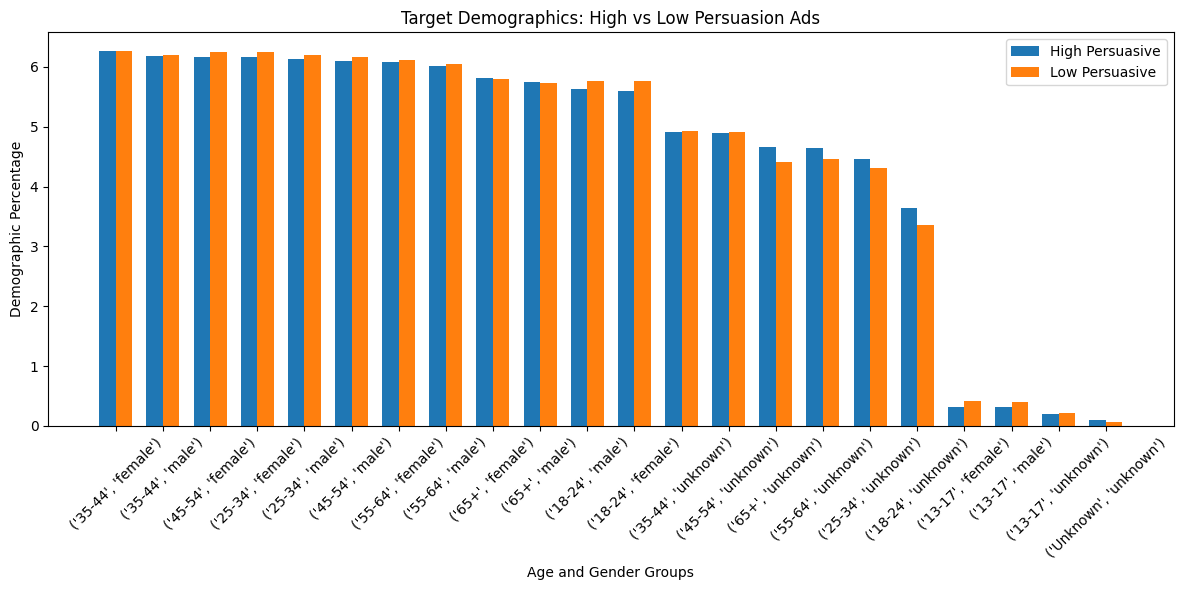

In [18]:
import matplotlib.pyplot as plt

# Demographics bar chart
combined = high_persuasive_demographics.join(low_persuasive_demographics, lsuffix='_high', rsuffix='_low')
combined = combined.sort_values(by='Count_high', ascending=False)

total_high = combined['Count_high'].sum()
total_low = combined['Count_low'].sum()
combined['Pct_high'] = (combined['Count_high'] / total_high) * 100
combined['Pct_low'] = (combined['Count_low'] / total_low) * 100

plt.figure(figsize=(12, 6))
width = 0.35
x = range(len(combined))
plt.bar(x, combined['Pct_high'], width, label='High Persuasive')
plt.bar([i + width for i in x], combined['Pct_low'], width, label='Low Persuasive')
plt.xlabel('Age and Gender Groups')
plt.ylabel('Demographic Percentage')
plt.xticks([i + width/2 for i in x], combined.index, rotation=45)
plt.legend()
plt.title('Target Demographics: High vs Low Persuasion Ads')
plt.tight_layout()
plt.show()

### Region Analysis

In [19]:
import ast

australian_regions = ['New South Wales', 'Victoria', 'Queensland', 'Western Australia',
                      'South Australia', 'Tasmania', 'Australian Capital Territory', 'Northern Territory']

def filter_australian_regions(ads_df):
    filtered = []
    for _, ad in ads_df.iterrows():
        region_groups = ast.literal_eval(ad['region_distribution'])
        if any(rg.get('region') in australian_regions for rg in region_groups):
            filtered.append(ad)
    return pd.DataFrame(filtered)

def calculate_total_ads_per_region(ads_df):
    totals = {}
    for _, ad in ads_df.iterrows():
        for rg in ast.literal_eval(ad['region_distribution']):
            region = rg.get('region')
            if region in australian_regions:
                totals.setdefault(region, 0)
                totals[region] += 1
    return totals

def calculate_ad_percentages(ads_df, region_totals):
    summary = {}
    for _, ad in ads_df.iterrows():
        for rg in ast.literal_eval(ad['region_distribution']):
            region = rg.get('region')
            if region in australian_regions:
                summary.setdefault(region, {'ad_count': 0})
                summary[region]['ad_count'] += 1
    for region in summary:
        total = region_totals.get(region, 1)
        summary[region]['ad_percentage'] = (summary[region]['ad_count'] / total) * 100
    return pd.DataFrame.from_dict(summary, orient='index').sort_values(by='ad_percentage', ascending=False).head(10)

high_au = filter_australian_regions(high_persuasive_ads)
low_au = filter_australian_regions(low_persuasive_ads)
region_totals = calculate_total_ads_per_region(pd.concat([high_au, low_au]))

print("High Persuasion — Top Regions:")
print(calculate_ad_percentages(high_au, region_totals))
print("\nLow Persuasion — Top Regions:")
print(calculate_ad_percentages(low_au, region_totals))

High Persuasion — Top Regions:
                              ad_count  ad_percentage
Northern Territory                2197      77.141854
Tasmania                          2568      76.496872
Australian Capital Territory      2444      76.089664
Western Australia                 3876      73.548387
South Australia                   2663      72.759563
New South Wales                   3194      71.791414
Queensland                        4400      71.672911
Victoria                          5056      66.605190

Low Persuasion — Top Regions:
                              ad_count  ad_percentage
Victoria                          2535      33.394810
Queensland                        1739      28.327089
New South Wales                   1255      28.208586
South Australia                    997      27.240437
Western Australia                 1394      26.451613
Australian Capital Territory       768      23.910336
Tasmania                           789      23.503128
Northern Territory  

### Persuasive Content Statistics

In [20]:
# Ads with at least one persuasive sentence
df_detailed['is_persuasive_single'] = df_detailed['sentence_classifications'].apply(lambda x: any(eval(x)))
persuasive_single = df_detailed['is_persuasive_single'].sum()
total = len(df_detailed)

print(f"Ads with at least one persuasive sentence: {persuasive_single}")
print(f"Ratio: {persuasive_single / total:.2f}")

# Average confidence for persuasive sentences
persuasive_scores = df_detailed['sentence_confidence_scores'].apply(
    lambda scores: [s for s in eval(scores) if s > 0.5]
)
avg_conf = np.mean([s for sublist in persuasive_scores for s in sublist])
print(f"Average confidence for persuasive sentences: {avg_conf:.2f}")

Ads with at least one persuasive sentence: 29535
Ratio: 0.86
Average confidence for persuasive sentences: 0.85


### Spending & Impressions Comparison

In [21]:
# Compute average spending and impressions
high_persuasive_ads = high_persuasive_ads.copy()
low_persuasive_ads = low_persuasive_ads.copy()

high_persuasive_ads['avg_impressions'] = (high_persuasive_ads['impressions.lower_bound'] + high_persuasive_ads['impressions.upper_bound']) / 2
high_persuasive_ads['avg_spending'] = (high_persuasive_ads['spend.lower_bound'] + high_persuasive_ads['spend.upper_bound']) / 2

low_persuasive_ads['avg_impressions'] = (low_persuasive_ads['impressions.lower_bound'] + low_persuasive_ads['impressions.upper_bound']) / 2
low_persuasive_ads['avg_spending'] = (low_persuasive_ads['spend.lower_bound'] + low_persuasive_ads['spend.upper_bound']) / 2

avg_imp_high = high_persuasive_ads['avg_impressions'].mean()
avg_spd_high = high_persuasive_ads['avg_spending'].mean()
avg_imp_low = low_persuasive_ads['avg_impressions'].mean()
avg_spd_low = low_persuasive_ads['avg_spending'].mean()

comparison = pd.DataFrame({
    'Category': ['High Persuasive', 'Low Persuasive'],
    'Avg Impressions': [avg_imp_high, avg_imp_low],
    'Avg Spending ($)': [avg_spd_high, avg_spd_low]
})
print(comparison)

          Category  Avg Impressions  Avg Spending ($)
0  High Persuasive      8245.753794        119.395735
1   Low Persuasive      4969.459077         86.298066


### Temporal Dynamics

In [26]:
df_detailed['ad_delivery_start_time'] = pd.to_datetime(
    df_detailed['ad_delivery_start_time'],
    format='mixed',
    errors='coerce',
    utc=True
)

df_detailed['ad_delivery_stop_time'] = pd.to_datetime(
    df_detailed['ad_delivery_stop_time'],
    format='mixed',
    errors='coerce',
    utc=True
)

df_detailed['ad_duration'] = (
    df_detailed['ad_delivery_stop_time'] - df_detailed['ad_delivery_start_time']
).dt.days

avg_dur_high = df_detailed.loc[df_detailed['persuasive_ratio'] > 0.8, 'ad_duration'].mean()
avg_dur_low = df_detailed.loc[df_detailed['persuasive_ratio'] < 0.2, 'ad_duration'].mean()

print(f"Avg campaign duration - High persuasion: {avg_dur_high:.1f} days")
print(f"Avg campaign duration - Low persuasion:  {avg_dur_low:.1f} days")


Avg campaign duration - High persuasion: 6.5 days
Avg campaign duration - Low persuasion:  6.3 days


### Impression-to-Spend Efficiency

In [23]:
# Load full ads DataFrame and merge with predictions
df_full = pd.read_csv(os.path.join(DATA_ADS, "australian_ads_dataframe.csv"))
unique_detail = pd.read_csv(os.path.join(DATA_ADS, "detailed_ads_df.csv"))

merged_df = pd.merge(df_full, unique_detail[['id', 'sentence_classifications', 'persuasive_ratio',
                                              'sentence_confidence_scores', 'sentence_lengths']],
                     on='id', how='left')

# Group by ad ID and compute impression-to-spend ratio
ad_grouped = merged_df.groupby('id').agg({
    'impressions.lower_bound': 'sum',
    'spend.lower_bound': 'sum',
    'persuasive_ratio': 'mean'
}).reset_index()

epsilon = 1e-8
ad_grouped['impression_to_spend_ratio'] = ad_grouped['impressions.lower_bound'] / (ad_grouped['spend.lower_bound'] + epsilon)

high_grouped = ad_grouped[ad_grouped['persuasive_ratio'] > 0.8]
low_grouped = ad_grouped[ad_grouped['persuasive_ratio'] < 0.2]

print(f"Avg impression/spend ratio — High persuasion: {high_grouped['impression_to_spend_ratio'].mean():.2f}")
print(f"Avg impression/spend ratio — Low persuasion:  {low_grouped['impression_to_spend_ratio'].mean():.2f}")

Avg impression/spend ratio — High persuasion: 153971564001.57
Avg impression/spend ratio — Low persuasion:  157214577922.63
